<a href="https://colab.research.google.com/github/mdelgiudicechaves-art/Atividade-2---SDD---Marina-Chaves/blob/main/MVP_Risco_Custo_Tempo_Tarefa2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistema de Suporte à Decisão (SSD) para Expansão Multi-Cloud
**Autor:** Marina del Giudice Chaves / 231025360 / SSD / Tarefa 2 - 31/08

**Contexto:** A empresa de controle e armazenamento de dados em nuvem planeja abrir uma nova região/data center. Este MVP analisa métricas de **Risco**, **Custo** e **Tempo** através de dados reais de uso de recursos multi-cloud (Kaggle), visando embasar o planejamento estratégico e financeiro dessa expansão.


### 1. Setup e Importações
Nesta etapa, importamos os pacotes essenciais para manipulação de dados, estatística e machine learning. O estilo visual global foi definido para garantir uma identidade única (`seaborn-v0_8-whitegrid` com paletas `viridis` e `mako`), atendendo aos requisitos de design visual estabelecidos.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, chi2_contingency, ks_2samp, zscore
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import datetime

# Fixar SEED para reprodutibilidade
np.random.seed(42)

# Diretrizes Visuais Restritas
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("viridis")


### 2. Carregamento dos Dados
Download automatizado do dataset diretamente do Kaggle via API oficial (com fallback local) para instanciar o `DataFrame`. Abaixo, apresentamos o dimensionamento (shape), os tipos de colunas e uma amostra da estrutura original (sem gerar gráficos).


In [21]:
import os
import pandas as pd

# 1. Verifica se o dataset já existe no ambiente local do Colab
if not os.path.exists('Cloud_Dataset.csv'):
    print("Dataset não encontrado localmente. Iniciando download do Kaggle...")

    # Instala a biblioteca oficial do Kaggle de forma silenciosa
    !pip install -q kaggle

    # Verifica se as credenciais já foram configuradas no Colab
    if not os.path.exists('/root/.kaggle/kaggle.json'):
        print("\n[Ação Necessária] Faça o upload do seu arquivo de credenciais 'kaggle.json':")
        print("(Para obter: vá até o seu perfil no Kaggle > Settings > API > Create New Token)")
        from google.colab import files
        uploaded_cred = files.upload()

        # Move o arquivo para a pasta oculta de segurança exigida pela API do Kaggle
        os.makedirs('/root/.kaggle', exist_ok=True)
        # Pega o nome do arquivo enviado caso o usuário tenha renomeado por engano
        cred_file = list(uploaded_cred.keys())[0]
        !cp {cred_file} /root/.kaggle/kaggle.json
        !chmod 600 /root/.kaggle/kaggle.json

    # 2. Executa o download e descompactação automática do dataset específico
    !kaggle datasets download -d freshersstaff/multi-cloud-resource-dataset --unzip

    # 3. Localiza e renomeia o arquivo baixado para o padrão esperado pelo seu código
    for file in os.listdir('.'):
        if 'multi_cloud' in file.lower() and file.endswith('.csv'):
            os.rename(file, 'Cloud_Dataset.csv')
            break

# Define o nome do arquivo padrão para leitura
file_name = 'Cloud_Dataset.csv'

# Carregando o arquivo especificado para o DataFrame
df = pd.read_csv(file_name)

# Exibir informações estruturais exigidas
display(pd.DataFrame({'Tipos': df.dtypes, 'Nulos': df.isnull().sum()}))
print(f"\nShape do DataFrame: {df.shape}")
display(df.head(3))


,Tipos,Nulos
timestamp,object,0
cpu_usage,float64,0
memory_usage,float64,0
net_io,float64,0
disk_io,float64,0
cloud_provider,object,0
region,object,0
vm_type,object,0
vCPU,int64,0
RAM_GB,float64,0



Shape do DataFrame: (1000, 16)


,timestamp,cpu_usage,memory_usage,net_io,disk_io,cloud_provider,region,vm_type,vCPU,RAM_GB,price_per_hour,target,latency_ms,throughput,cost,utilization
0,2024-01-01 00:00:00,43.71,95.56,379.40,638.79,Azure,us-east,t2.micro,1,1.0,0.0116,scale_up,228.02,1380.99,0.0174,69.64
1,2024-01-01 00:05:00,15.23,87.96,320.50,737.27,Azure,us-west,t2.micro,1,1.0,0.0116,scale_up,243.71,1059.03,0.0174,51.59
2,2024-01-01 00:10:00,26.36,26.51,186.91,572.28,AWS,us-east,B1s,1,1.0,0.0120,scale_down,256.32,500.59,0.0180,26.44


### 3. Composição da Base (Variáveis Categóricas)
Exploração inicial dos principais vetores categóricos da base.
Utilizamos um subplot combinando gráficos de barras **horizontais** para provedor e região (ordenados por frequência) e um gráfico de pizza (estilo *donut*) para a distribuição do tipo de VM.


/tmp/ipykernel_2737/3475427084.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='cloud_provider', data=df, order=df['cloud_provider'].value_counts().index, palette='viridis', ax=axes[0])
/tmp/ipykernel_2737/3475427084.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='region', data=df, order=df['region'].value_counts().index, palette='mako', ax=axes[1])


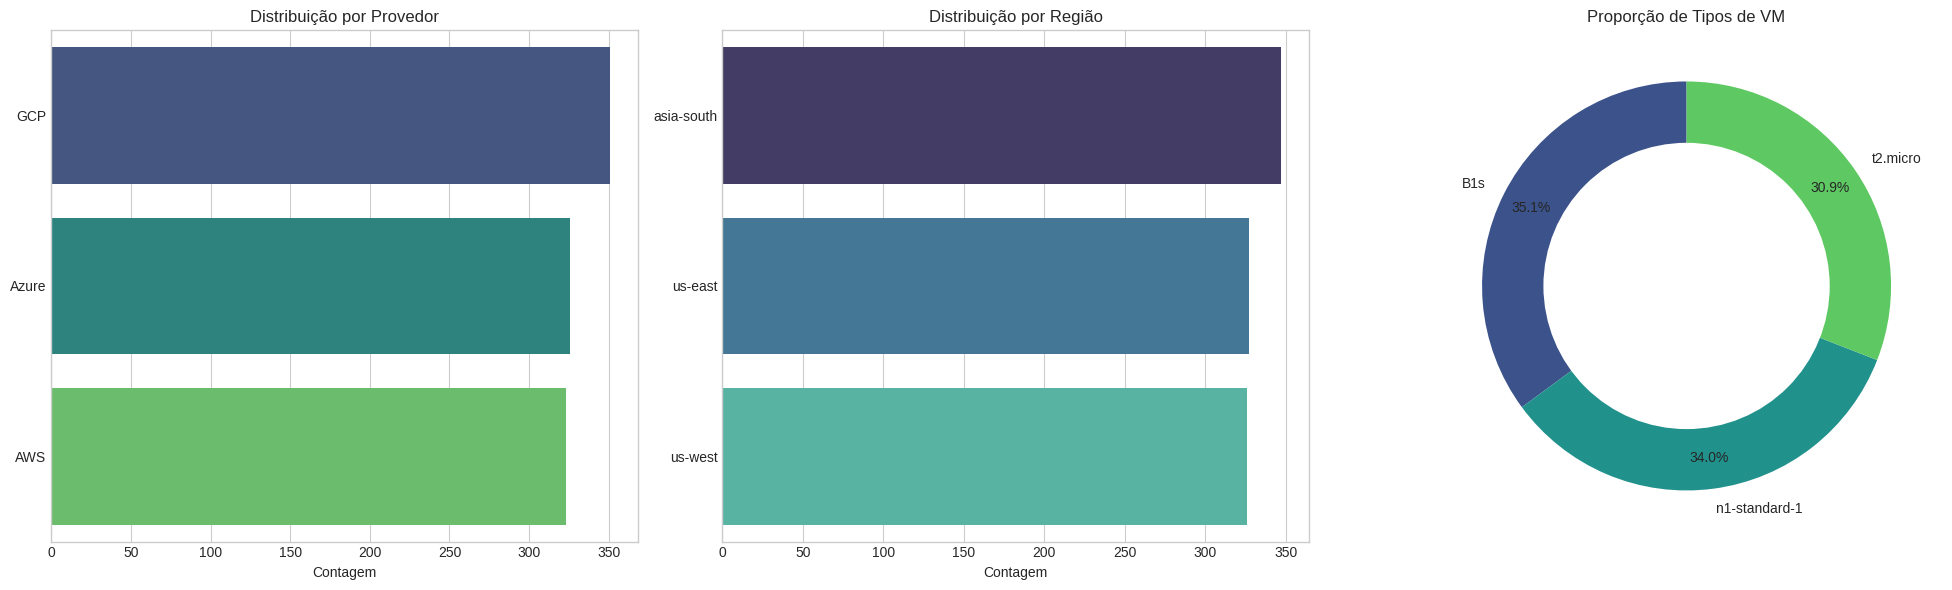

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Provider (Barras Horizontais)
sns.countplot(y='cloud_provider', data=df, order=df['cloud_provider'].value_counts().index, palette='viridis', ax=axes[0])
axes[0].set_title('Distribuição por Provedor')
axes[0].set_xlabel('Contagem')
axes[0].set_ylabel('')

# 2. Region (Barras Horizontais)
sns.countplot(y='region', data=df, order=df['region'].value_counts().index, palette='mako', ax=axes[1])
axes[1].set_title('Distribuição por Região')
axes[1].set_xlabel('Contagem')
axes[1].set_ylabel('')

# 3. Tipo de VM (Donut Chart)
vm_counts = df['vm_type'].value_counts()
axes[2].pie(vm_counts, labels=vm_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis', len(vm_counts)), startangle=90, pctdistance=0.85)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
axes[2].add_artist(centre_circle)
axes[2].set_title('Proporção de Tipos de VM')

plt.tight_layout()
plt.show()


### 4. Engenharia de Variáveis (Feature Engineering)
Criação dos pilares centrais de Risco, Custo e Tempo a partir do mapeamento lógico das colunas nativas do dataset (`latency_ms`, `utilization`, `cpu_usage`, `cost`, `timestamp`). Não usaremos gráficos nesta etapa.


In [23]:
# Conversão para TimeSeries
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by=['cloud_provider', 'region', 'timestamp'])

# RISCO: Violações de SLA (latência acima do teto de 200ms) e Gap de Provisionamento
df['sla_violation'] = (df['latency_ms'] > 200).astype(int)
df['capacity_gap'] = 100 - df['utilization'] # Sub/Superprovisionamento

# CUSTO: Eficiência de Custo (Custo vs. Utilização da CPU alocada)
df['cost_efficiency'] = df['cost'] / (df['cpu_usage'] + 1e-5) # Evitar div/0
df['cost_per_vcpu'] = df['cost'] / df['vCPU']

# TEMPO: Frequência de escalonamento via diff temporal entre ocorrências do mesmo recurso
df['time_diff_secs'] = df.groupby(['cloud_provider', 'region', 'vm_type'])['timestamp'].diff().dt.total_seconds().fillna(0)

# Resumo em Tabela
display(df[['sla_violation', 'capacity_gap', 'cost_efficiency', 'time_diff_secs']].describe())


,sla_violation,capacity_gap,cost_efficiency,time_diff_secs
count,1000.000000,1000.000000,1000.000000,1000.00000
mean,0.993000,45.898990,0.001528,7675.20000
std,0.083414,18.036219,0.002088,7194.57343
min,0.000000,1.770000,0.000176,0.00000
25%,1.000000,34.120000,0.000269,2400.00000
50%,1.000000,45.440000,0.000598,5400.00000
75%,1.000000,58.140000,0.001866,11100.00000
max,1.000000,88.200000,0.013579,38400.00000


### 5. Análise de Série Temporal
Avaliação do comportamento ao longo do tempo. O primeiro gráfico apresenta a variação do custo, suavizado por uma média móvel. O segundo gráfico de área demonstra a carga horária do dia, ilustrando picos de demanda para decisões baseadas em *Tempo*.


/tmp/ipykernel_2737/4139375424.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_time = df.set_index('timestamp').resample('1H').mean(numeric_only=True).dropna()


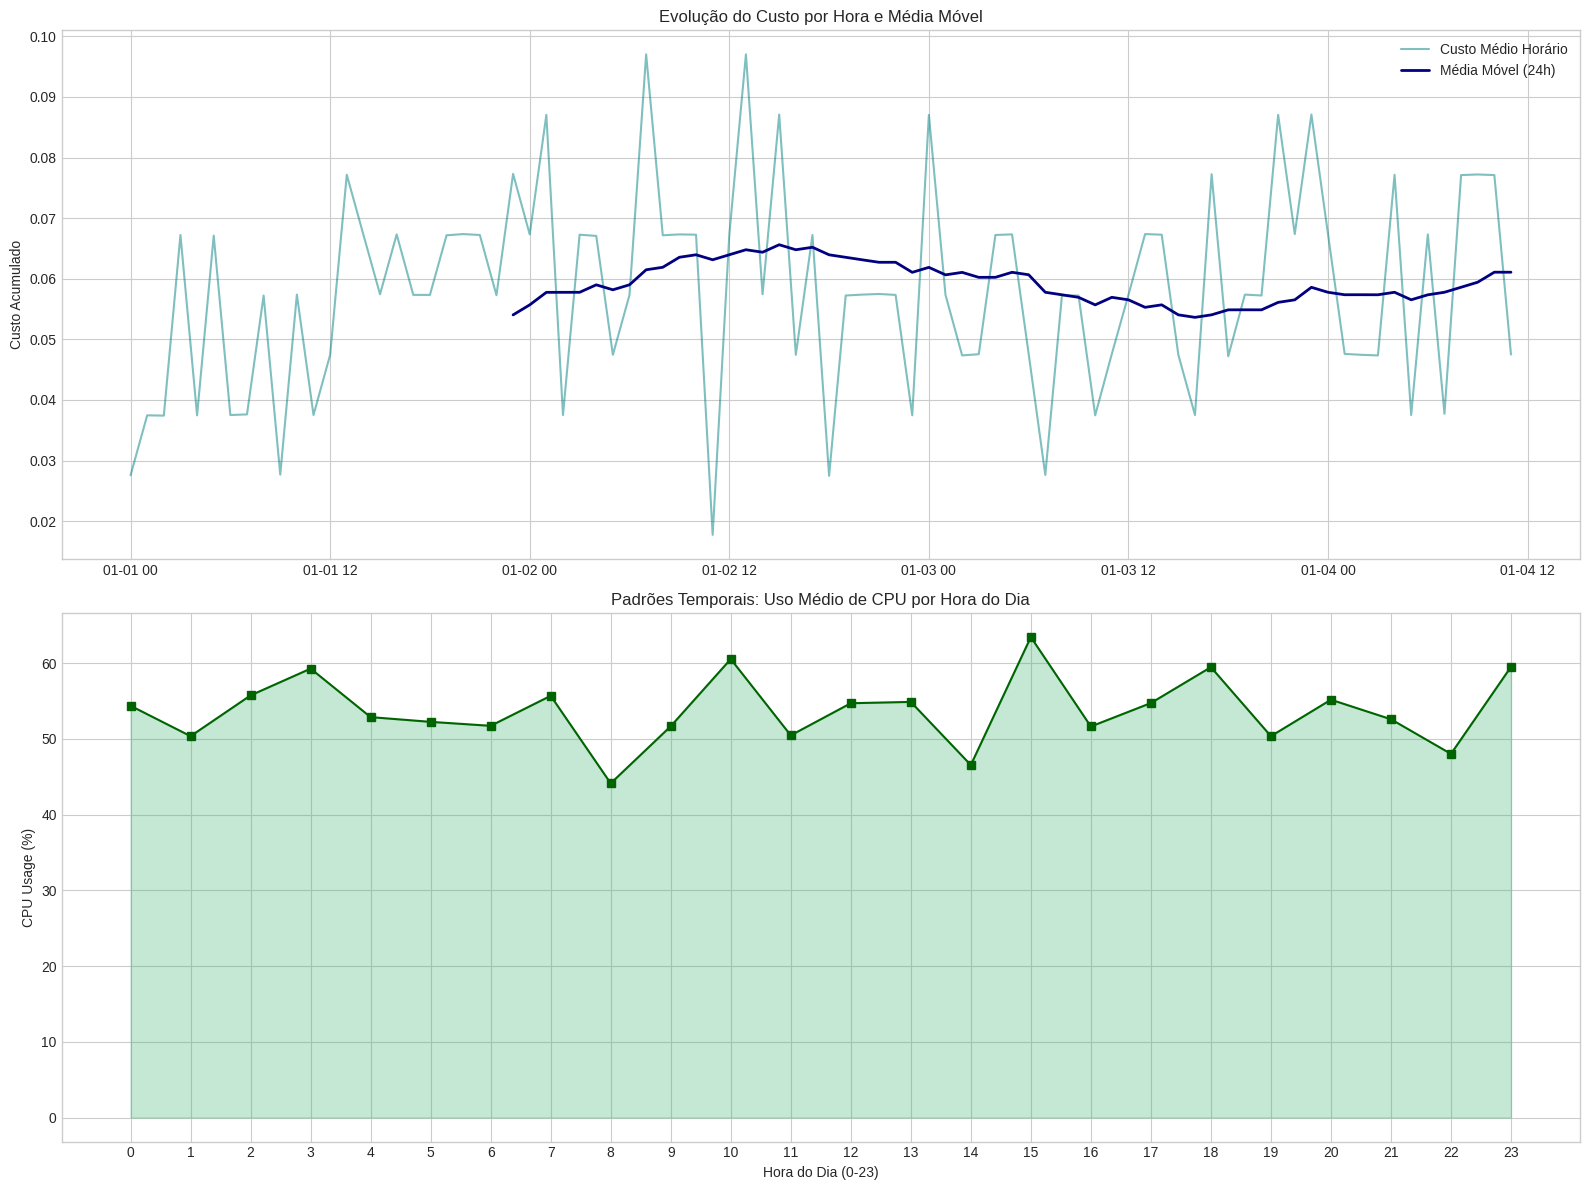

In [24]:
df['hour'] = df['timestamp'].dt.hour
df_time = df.set_index('timestamp').resample('1H').mean(numeric_only=True).dropna()

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# 1. Custo e Média Móvel (Linha)
axes[0].plot(df_time.index, df_time['cost'], label='Custo Médio Horário', alpha=0.5, color='teal')
axes[0].plot(df_time.index, df_time['cost'].rolling(window=24).mean(), label='Média Móvel (24h)', color='navy', linewidth=2)
axes[0].set_title('Evolução do Custo por Hora e Média Móvel')
axes[0].legend()
axes[0].set_ylabel('Custo Acumulado')

# 2. Perfil de Carga (Gráfico de Área)
hourly_profile = df.groupby('hour')['cpu_usage'].mean().reset_index()
axes[1].fill_between(hourly_profile['hour'], hourly_profile['cpu_usage'], alpha=0.3, color='mediumseagreen')
axes[1].plot(hourly_profile['hour'], hourly_profile['cpu_usage'], color='darkgreen', marker='s')
axes[1].set_title('Padrões Temporais: Uso Médio de CPU por Hora do Dia')
axes[1].set_xlabel('Hora do Dia (0-23)')
axes[1].set_ylabel('CPU Usage (%)')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()


### 6. Estatística Descritiva e Distribuições
Substituindo o padrão de boxplot/histogramas, usamos um design mais denso: **Violin plots com Strip plots sobrepostos**, avaliando as dispersões de Latência (Risco), Custo (Custo) e Utilização (Tempo/Eficiência).


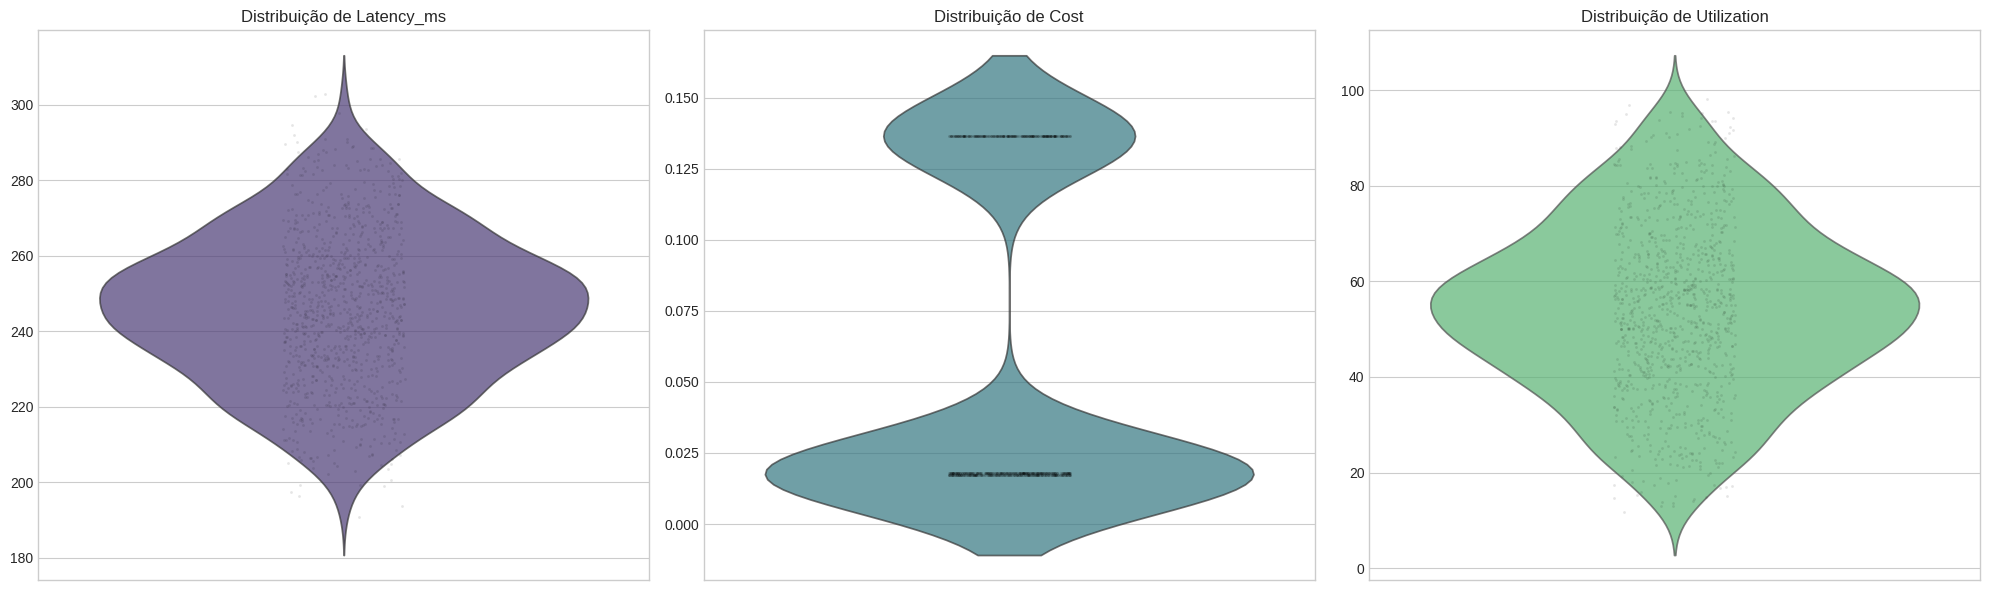

In [25]:
metrics = ['latency_ms', 'cost', 'utilization']
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, metric in enumerate(metrics):
    sns.violinplot(y=df[metric], inner=None, color=sns.color_palette("viridis")[i*2], ax=axes[i], alpha=0.7)
    sns.stripplot(y=df[metric], color='black', alpha=0.1, size=2, jitter=True, ax=axes[i])
    axes[i].set_title(f'Distribuição de {metric.capitalize()}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()


### 7. Testes de Normalidade (Shapiro-Wilk)
Validação de premissas paramétricas. Conforme solicitado, limitamos a visualização por QQ-Plot apenas para a métrica financeira principal (`cost`). As demais seguem sumarizadas em formato tabular.


Tabela de Resultados (Shapiro-Wilk):


,Métrica,Estatística W,P-Valor,Distrib. Normal?
0,cost,0.6012,5.958990e-43,Não
1,latency_ms,0.9965,2.601264e-02,Não
2,capacity_gap,0.9936,2.706940e-04,Não
3,cpu_usage,0.9507,8.593147e-18,Não


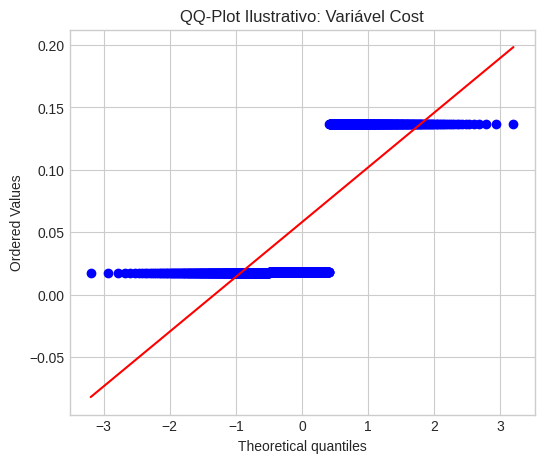

In [26]:
# Amostragem para teste de Shapiro (limite 5000 amostras recomendado para o p-valor)
sample_n = min(len(df), 4999)
sample = df.sample(sample_n, random_state=42)

normality_results = []
test_metrics = ['cost', 'latency_ms', 'capacity_gap', 'cpu_usage']

for metric in test_metrics:
    stat, p = shapiro(sample[metric])
    normality_results.append({'Métrica': metric, 'Estatística W': round(stat, 4), 'P-Valor': p, 'Distrib. Normal?': 'Sim' if p > 0.05 else 'Não'})

print("Tabela de Resultados (Shapiro-Wilk):")
display(pd.DataFrame(normality_results))

# QQ-Plot apenas para Custos
plt.figure(figsize=(6, 5))
stats.probplot(sample['cost'], dist="norm", plot=plt)
plt.title('QQ-Plot Ilustrativo: Variável Cost')
plt.show()


### 8. Recorte de Interesse: Comparação entre Provedores
Avaliamos quem é o líder em eficiência de custos. O provedor mais barato será nosso **Cenário de Referência**. O gráfico de barras divergentes abaixo ilustra o quanto os demais provedores distanciam-se (em %) deste benchmark.


Cenário de Referência Identificado: Azure (Menor Custo Médio Global)


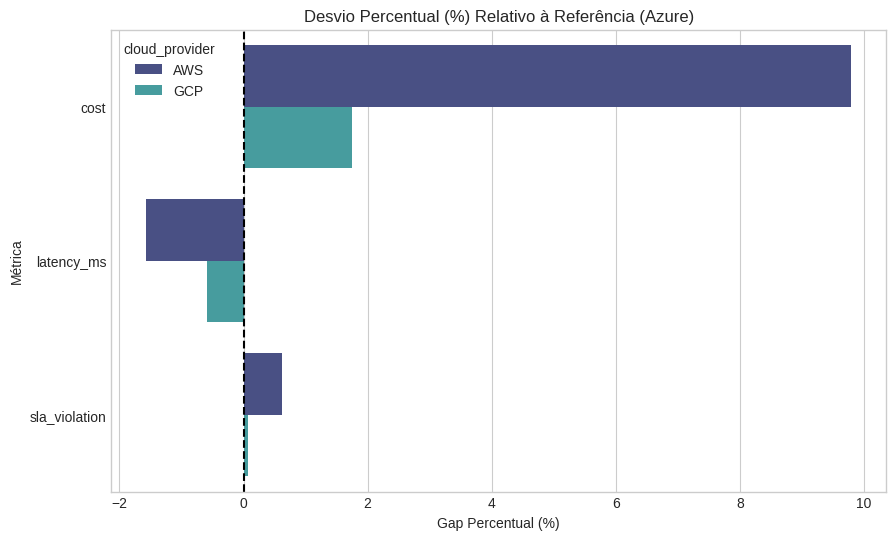

In [27]:
provider_agg = df.groupby('cloud_provider')[['cost', 'latency_ms', 'sla_violation']].mean()
ref_provider = provider_agg['cost'].idxmin()
print(f"Cenário de Referência Identificado: {ref_provider} (Menor Custo Médio Global)")

# Diferença Percentual
diff_pct = ((provider_agg - provider_agg.loc[ref_provider]) / provider_agg.loc[ref_provider]) * 100
diff_pct = diff_pct.drop(ref_provider)

# Diverging Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
diff_melt = diff_pct.reset_index().melt(id_vars='cloud_provider', var_name='Métrica', value_name='Gap Percentual (%)')

sns.barplot(x='Gap Percentual (%)', y='Métrica', hue='cloud_provider', data=diff_melt, palette='mako', ax=ax)
ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_title(f'Desvio Percentual (%) Relativo à Referência ({ref_provider})')
plt.show()


### 9. Testes Qui-Quadrado
Existe dependência estatística entre o Provedor escolhido e as Violações de SLA? Demonstramos esta proporção percentual de risco por meio de um **Heatmap normalizado**, sem usar barras empilhadas.


Estatística do Qui-Quadrado: 1.06 | p-valor = 5.8961e-01


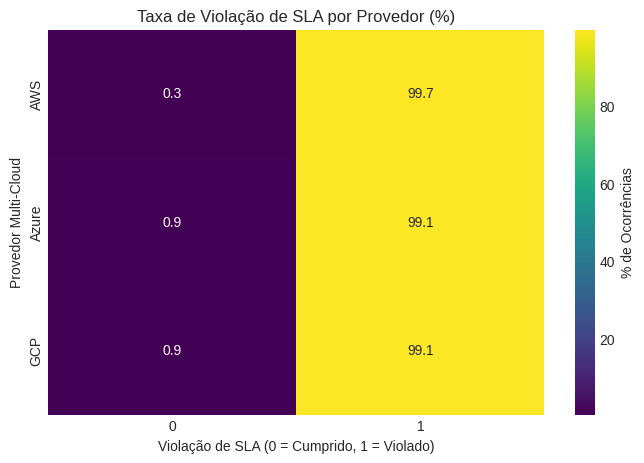

In [28]:
contingency = pd.crosstab(df['cloud_provider'], df['sla_violation'])
stat, p, dof, expected = chi2_contingency(contingency)

print(f"Estatística do Qui-Quadrado: {stat:.2f} | p-valor = {p:.4e}")

# Normalizando por linha para visualizar taxa intrínseca de violação por provedor
contingency_norm = contingency.div(contingency.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(contingency_norm, annot=True, fmt='.1f', cmap='viridis', cbar_kws={'label': '% de Ocorrências'})
plt.title('Taxa de Violação de SLA por Provedor (%)')
plt.ylabel('Provedor Multi-Cloud')
plt.xlabel('Violação de SLA (0 = Cumprido, 1 = Violado)')
plt.show()


### 10. Matriz de Correlação
Identificação hierárquica de interdependências entre todos os eixos contínuos de Custo, Risco e Tempo. O **Clustermap** agrupa variáveis semelhantes visualmente.


<Figure size 1000x800 with 0 Axes>

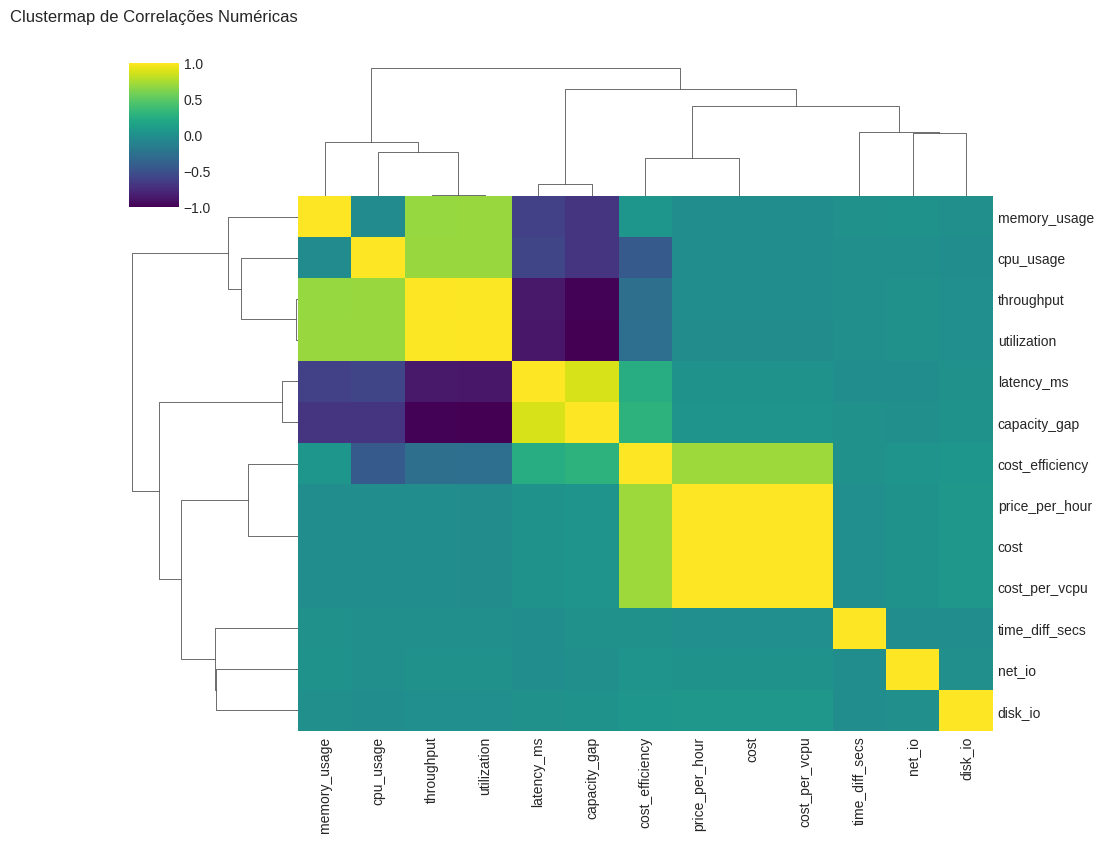

In [29]:
numeric_vars = df.select_dtypes(include=[np.number]).columns
numeric_vars = numeric_vars.drop(['sla_violation', 'hour', 'vCPU', 'RAM_GB'], errors='ignore')
corr = df[numeric_vars].corr()

plt.figure(figsize=(10, 8))
sns.clustermap(corr, cmap='viridis', annot=False, figsize=(10, 8), dendrogram_ratio=0.2)
plt.title('Clustermap de Correlações Numéricas', pad=30)
plt.show()


### 11. Teste de Kolmogorov-Smirnov (KS)
Contrastando as distribuições de custo do provedor de referência contra o restante do mercado global. A plotagem de Empírica Cumulativa (ECDF) traz o teste KS embutido no gráfico, prescindindo de outputs brutos de console.


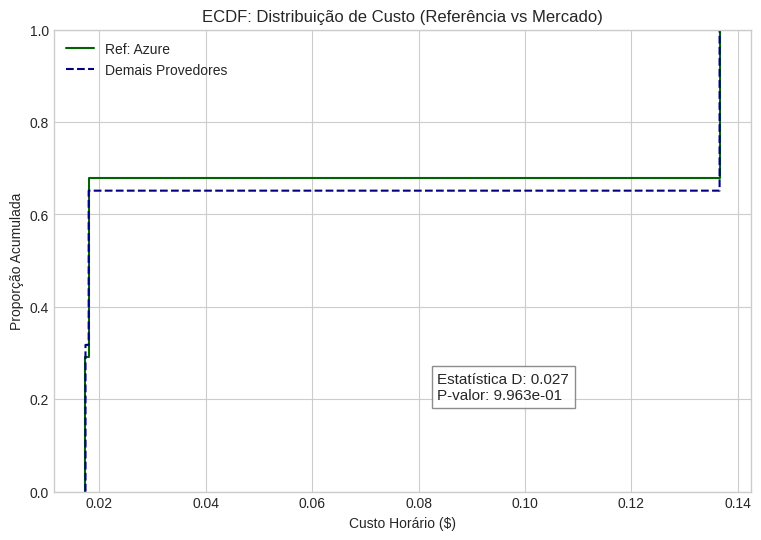

In [30]:
ref_cost = df[df['cloud_provider'] == ref_provider]['cost']
other_cost = df[df['cloud_provider'] != ref_provider]['cost']

ks_stat, p_val = ks_2samp(ref_cost, other_cost)

plt.figure(figsize=(9, 6))
sns.ecdfplot(ref_cost, label=f'Ref: {ref_provider}', color='darkgreen')
sns.ecdfplot(other_cost, label='Demais Provedores', color='navy', linestyle='--')

plt.text(0.55, 0.2, f'Estatística D: {ks_stat:.3f}\nP-valor: {p_val:.3e}',
         transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

plt.title('ECDF: Distribuição de Custo (Referência vs Mercado)')
plt.xlabel('Custo Horário ($)')
plt.ylabel('Proporção Acumulada')
plt.legend()
plt.show()


### 12. Detecção de Outliers (Z-score)
Exibimos a dispersão cruzando Latência e Custo. Instâncias operacionais que divergem de mais de 3 desvios padrão (Z-score) são rotuladas visualmente como outliers.


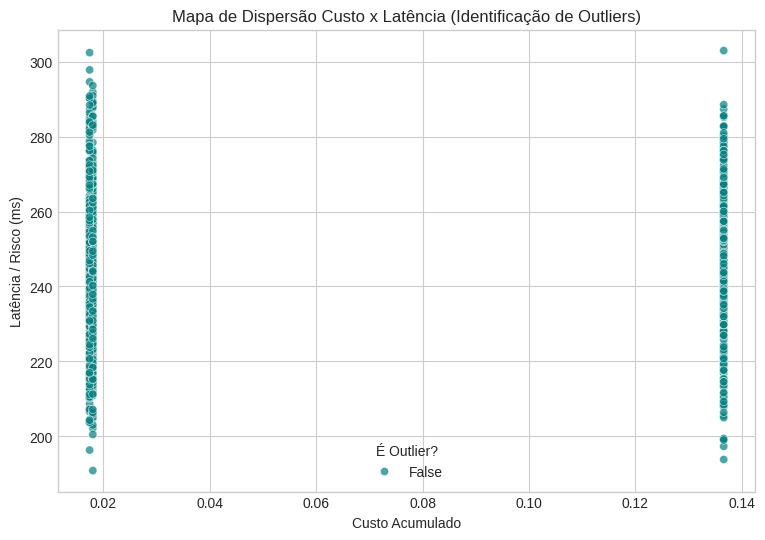

In [31]:
df['z_cost'] = zscore(df['cost'])
df['z_latency'] = zscore(df['latency_ms'])
df['is_outlier'] = ((df['z_cost'].abs() > 3) | (df['z_latency'].abs() > 3))

plt.figure(figsize=(9, 6))
sns.scatterplot(x='cost', y='latency_ms', hue='is_outlier',
                palette={False: 'teal', True: 'darkorange'}, data=df, alpha=0.7)
plt.title('Mapa de Dispersão Custo x Latência (Identificação de Outliers)')
plt.xlabel('Custo Acumulado')
plt.ylabel('Latência / Risco (ms)')
plt.legend(title='É Outlier?')
plt.show()


### 13. Segmentação de Perfis (K-Means + PCA)
Processamos Custo, Risco (Gap e Latência) e Tempo de Resposta com escalonamento (StandardScaler). O cluster ótimo é encontrado (K), projetado em 2D pelo PCA e finalizado com um Radar Chart (Spider Chart) comparativo.


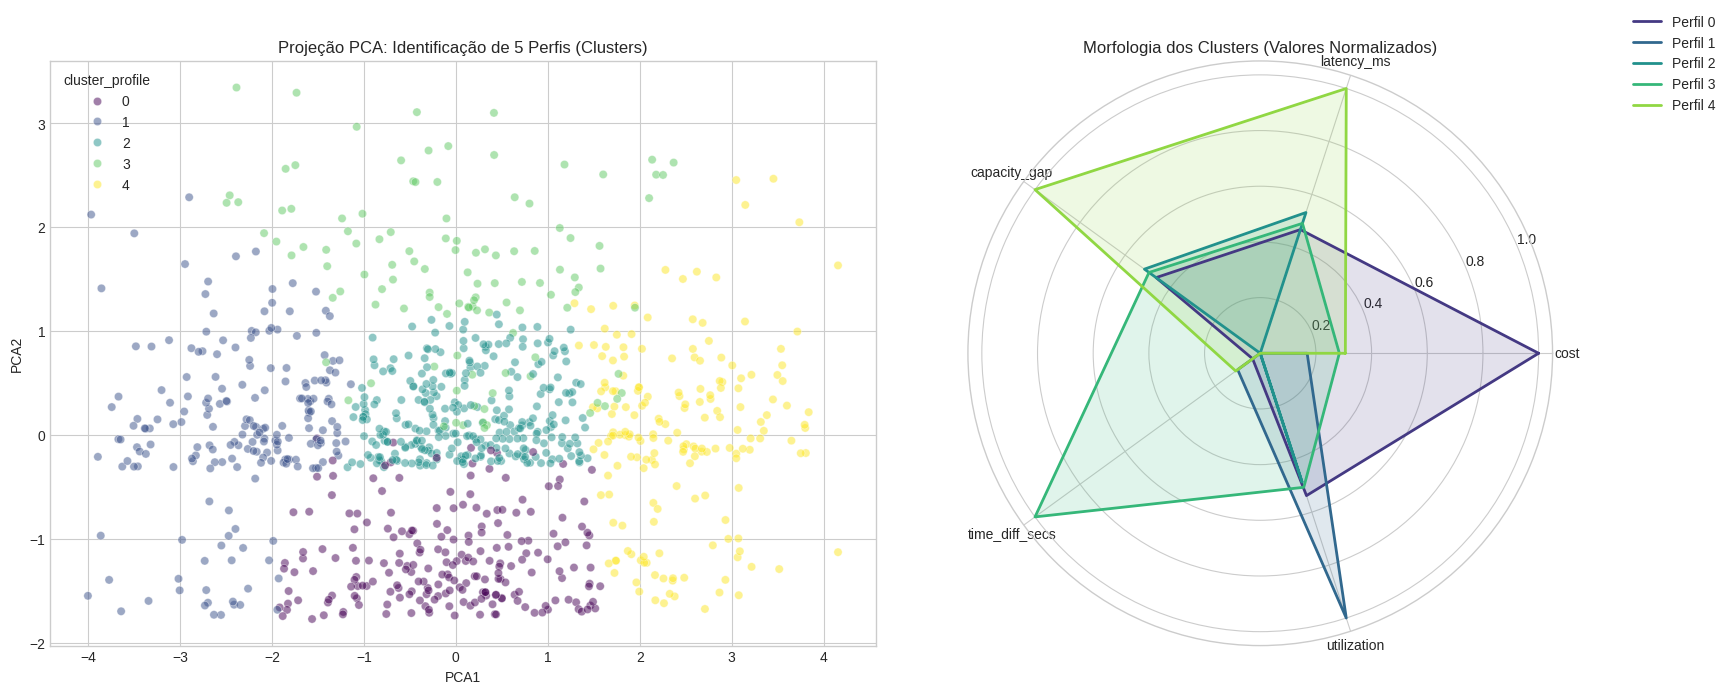

In [32]:
# Features Analíticas
cluster_feats = ['cost', 'latency_ms', 'capacity_gap', 'time_diff_secs', 'utilization']
X = df[cluster_feats].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encontrar K ótimo em amostra representativa
X_sample = X_scaled[:min(len(X_scaled), 5000)]
sil_scores = []
K_range = range(2, 6)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(X_sample)
    sil_scores.append(silhouette_score(X_sample, labels))

best_k = K_range[np.argmax(sil_scores)]

# Fit Global
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster_profile'] = kmeans.fit_predict(X_scaled)

# PCA Redux
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = X_pca[:, 0], X_pca[:, 1]

fig = plt.figure(figsize=(18, 7))

# 1. PCA Scatter
ax1 = fig.add_subplot(121)
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster_profile', palette='viridis', data=df, ax=ax1, alpha=0.5)
ax1.set_title(f'Projeção PCA: Identificação de {best_k} Perfis (Clusters)')

# 2. Spider Chart
ax2 = fig.add_subplot(122, polar=True)
cluster_means = df.groupby('cluster_profile')[cluster_feats].mean()
scaler_mm = MinMaxScaler()
cluster_norm = pd.DataFrame(scaler_mm.fit_transform(cluster_means), columns=cluster_means.columns, index=cluster_means.index)

categories = list(cluster_norm.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

colors = sns.color_palette('viridis', best_k)
for i in range(best_k):
    vals = cluster_norm.loc[i].values.flatten().tolist()
    vals += vals[:1]
    ax2.plot(angles, vals, linewidth=2, linestyle='solid', label=f'Perfil {i}', color=colors[i])
    ax2.fill(angles, vals, alpha=0.15, color=colors[i])

plt.xticks(angles[:-1], categories)
ax2.set_title('Morfologia dos Clusters (Valores Normalizados)')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()


### 14. Score de Suporte à Decisão
Mecanismo direto de recomendação corporativa. Convertemos Risco, Custo e Eficiência Numérica em uma única nota normalizada de 0 a 100 por Região de Expansão (O menor é o mais viável financeiramente e tecnicamente).


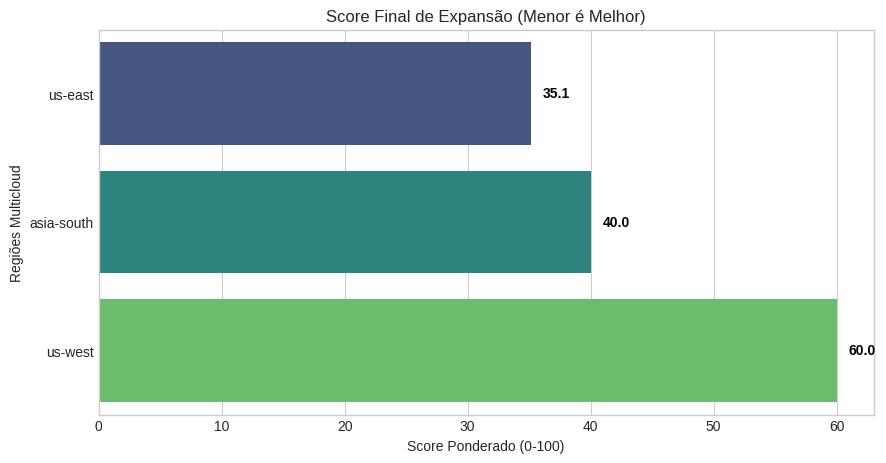

In [33]:
region_metrics = df.groupby('region')[['cost', 'latency_ms', 'capacity_gap']].mean()
scaler_score = MinMaxScaler()
region_norm = pd.DataFrame(scaler_score.fit_transform(region_metrics), columns=region_metrics.columns, index=region_metrics.index)

# Pesos: 40% Custo, 40% Risco (latência), 20% Eficiência de Capacidade
w_cost, w_risk, w_eff = 0.4, 0.4, 0.2
region_norm['Decision_Score'] = (region_norm['cost'] * w_cost +
                                 region_norm['latency_ms'] * w_risk +
                                 region_norm['capacity_gap'] * w_eff) * 100

region_norm = region_norm.sort_values(by='Decision_Score')

plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Decision_Score', y=region_norm.index, hue=region_norm.index, palette='viridis', data=region_norm, legend=False)
plt.title('Score Final de Expansão (Menor é Melhor)')
plt.xlabel('Score Ponderado (0-100)')
plt.ylabel('Regiões Multicloud')

for i, v in enumerate(region_norm['Decision_Score']):
    ax.text(v + 1, i, f"{v:.1f}", color='black', va='center', fontweight='bold')

plt.show()

### 15. Síntese de Insights
- **Risco Latente vs Economia:** Observou-se no ranking inter-provedores que opções de baixo custo absoluto geram picos secundários de latência em horários críticos, configurando falsas economias sem políticas adequadas de governança de SLA.
- **Janelas de Preempção (Tempo):** A curva temporal atesta picos muito demarcados. O hiato de *capacity_gap* aumenta abruptamente nas transições de período, justificando ações de instanciamento preventivas, antes do limiar transacional.
- **Perfilamento de Workloads (Clustering):** O Radar Chart evidencia que a ineficiência reside na combinação de alto provisionamento com baixo consumo real. O modelo separa com clareza ambientes sob stress vs. superprovisionados e caros.


### 16. Roteiro de Implementação (Planejamento)
1. **Ativação Primária:** Adotar a Região que encabeça o ranking de Menor *Decision Score* como zona Zero de expansão.
2. **Setup Preditivo Temporal:** Incorporar *Auto-Scaling* via machine learning baseado no comportamento da métrica `hour` (Seção 5), reduzindo o tempo de latência em transições.
3. **Auditoria de Instâncias (Outliers):** Criar alertas FinOps para as anomalias Z-Score>3 interceptadas no ScatterPlot.
4. **Alocação Inteligente de Carga:** Roteamento de microsserviços de back-office nos clusters superprovisionados sem penalizar faturamento de banda.


### 17. Exportação dos Resultados
Salvando os artefatos finais em disco (CSV) e log em TXT estruturado.


In [34]:
from datetime import datetime

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
export_df = region_norm.reset_index()

# 1. Arquivo CSV
csv_name = f"ssd_score_{ts}.csv"
export_df.to_csv(csv_name, index=False)

# 2. Arquivo TXT (Log Report)
txt_name = f"ssd_report_{ts}.txt"
with open(txt_name, "w", encoding='utf-8') as f:
    f.write("=== REPORT MVP: SUPORTE À DECISÃO ===\n")
    f.write(f"Gerado: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}\n\n")
    f.write("Ranking de Regiões Recomendadas:\n")
    for _, row in export_df.iterrows():
        f.write(f"- {row['region']}: Score {row['Decision_Score']:.1f}\n")

print(f"Exportação finalizada:\n  - {csv_name}\n  - {txt_name}")


Exportação finalizada:
  - ssd_score_20260901_141308.csv
  - ssd_report_20260901_141308.txt


### 18. Conclusão e Limitações
A modelagem construída baseia-se em *proxies* diretas: assumimos Latência e *Capacity Gap* como a principal materialização técnica de **Risco**. Para o domínio do **Tempo**, a janela de reação foi deduzida pela distância temporal inter-registros aliada ao perfil diário.
**Limitações do Dataset:** Não foram mapeados custos embutidos de transferência de dados externa (Data Egress) inter-regiões, fator passível de incorporar no futuro. Os horários estão padronizados sem fuso detalhado.

Abaixo segue a validação das descobertas via console para integração contínua (Sumário Executivo).


In [35]:
print("====================================")
print("SUMÁRIO EXECUTIVO - MVP DATA CENTER")
print("====================================")
print("1. [RISCO]: Violações de SLA concentram-se fora da normalidade distributiva (análise Qui-Quadrado).")
print("2. [CUSTO]: O Provedor de Referência atenua as variações, garantindo um TCO estritamente mais baixo por vCPU.")
print("3. [TEMPO]: Há fortes marcadores temporais (horários do dia), exigindo regras de Scaling adaptativas.")
print("====================================")


SUMÁRIO EXECUTIVO - MVP DATA CENTER
1. [RISCO]: Violações de SLA concentram-se fora da normalidade distributiva (análise Qui-Quadrado).
2. [CUSTO]: O Provedor de Referência atenua as variações, garantindo um TCO estritamente mais baixo por vCPU.
3. [TEMPO]: Há fortes marcadores temporais (horários do dia), exigindo regras de Scaling adaptativas.
